Phase 2: Credit Analysis

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')


Load Data

In [19]:
credit_applications_df = pd.read_csv(r"C:\Florence Personal\Documents\Data Science Projects\Amdari Accelerate Internship Projects Folder\FinRisk-ai-internship\data\raw\credit_applications.csv")
credit_bureau_data_df = pd.read_csv(r"C:\Florence Personal\Documents\Data Science Projects\Amdari Accelerate Internship Projects Folder\FinRisk-ai-internship\data\raw\credit_bureau_data.csv")
customer_profiles_df = pd.read_csv(r"C:\Florence Personal\Documents\Data Science Projects\Amdari Accelerate Internship Projects Folder\FinRisk-ai-internship\data\raw\customer_profiles.csv")
model_predictions_df = pd.read_csv(r"C:\Florence Personal\Documents\Data Science Projects\Amdari Accelerate Internship Projects Folder\FinRisk-ai-internship\data\raw\model_predictions.csv")
transaction_data_df = pd.read_csv(r"C:\Florence Personal\Documents\Data Science Projects\Amdari Accelerate Internship Projects Folder\FinRisk-ai-internship\data\raw\transaction_data.csv")

In [20]:
credit_applications_df.head()

,application_id,customer_id,application_date,loan_amount,loan_purpose,employment_status,annual_income,debt_to_income_ratio,credit_score,application_status,default_flag
0,APP_0000001,CUST_008172,2023-09-03,164883,Home Purchase,Retired,85399.18,0.828,675,Declined,0
1,APP_0000002,CUST_016851,2023-05-02,59782,Home Purchase,Full-time,20582.50,1.005,677,Declined,0
2,APP_0000003,CUST_016766,2024-08-08,23716,Car Purchase,Part-time,11860.21,0.694,732,Declined,0
3,APP_0000004,CUST_018679,2024-07-22,13514,Car Purchase,Part-time,16490.54,0.710,850,Declined,0
4,APP_0000005,CUST_019411,2024-08-13,13992,Car Purchase,Part-time,9600.00,0.530,630,Declined,0


Phase 2: Credit Analysis
- Default rate by credit score ranges
    - Step 1: Define Credit Score Ranges

We’ll create bins (ranges) of credit scores. For example:

- Poor: 300–579

- Fair: 580–669

- Good: 670–739

- Very Good: 740–799

- Excellent: 800–850

(These are typical FICO-like ranges, but we can adjust depending on your dataset’s distribution.)

- Default rate by credit score ranges
    - Step 2: Compute Default Rates

Remember We have:

credit_score column existing (in our credit_bureau_data.csv, customer_profile.csv and credit_applications.csv).

default_flag column existsing in our credit_application.csv (1 = default, 0 = non-default).

In [ ]:
print(credit_applications_df.columns.tolist())

['application_id', 'customer_id', 'application_date', 'loan_amount', 'loan_purpose', 'employment_status', 'annual_income', 'debt_to_income_ratio', 'credit_score', 'application_status', 'default_flag']


           score_range  default_rate
0       Poor (300–579)      0.008840
1       Fair (580–669)      0.013975
2       Good (670–739)      0.021398
3  Very Good (740–799)      0.021353
4  Excellent (800–850)      0.020872


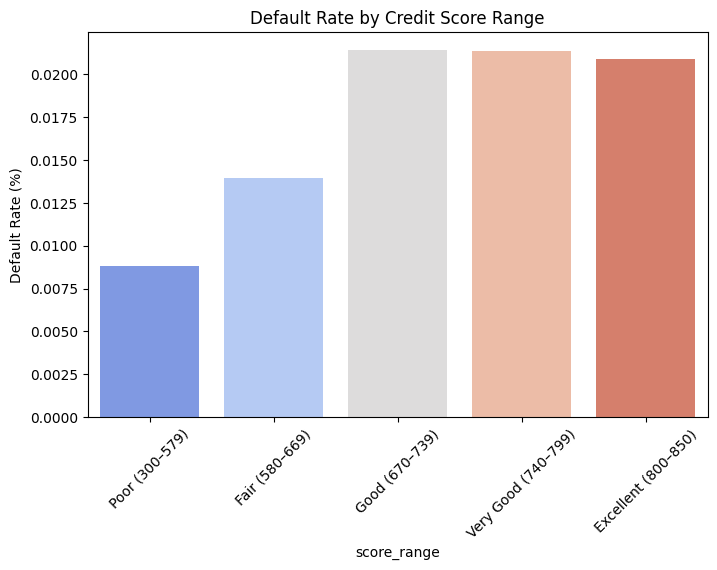

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define bins and labels
bins = [300, 579, 669, 739, 799, 850]
labels = ['Poor (300–579)', 'Fair (580–669)', 'Good (670–739)',
          'Very Good (740–799)', 'Excellent (800–850)']

# Create score ranges
credit_applications_df['score_range'] = pd.cut(
    credit_applications_df['credit_score'], bins=bins, labels=labels, right=True
)

# Calculate default rate by score range
default_rates = (
    credit_applications_df.groupby('score_range')['default_flag']
    .mean()
    .reset_index()
    .rename(columns={'default_flag': 'default_rate'})
)

print(default_rates)

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(x='score_range', y='default_rate', data=default_rates, palette="coolwarm")
plt.title("Default Rate by Credit Score Range")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=45)
plt.show()


- A table of default rates by score range.

- A visualization showing how risk decreases as credit score improves.

- Income vs loan amount relationships
    - step 1. Compute loan-to-income ratio (LIR)

In [31]:
credit_applications_df["loan_to_income_ratio"] = (
    credit_applications_df["loan_amount"] / credit_applications_df["annual_income"]
)
credit_applications_df["loan_to_income_ratio"].head()

0    1.930733
1    2.904506
2    1.999627
3    0.819500
4    1.457500
Name: loan_to_income_ratio, dtype: float64

- Income vs loan amount relationships
    - step 2. Summary statistics

In [27]:
credit_applications_df["loan_to_income_ratio"].describe()


count    100000.000000
mean          1.943417
std           2.951304
min           0.500020
25%           1.146718
50%           1.779327
75%           2.588915
max         386.100386
Name: loan_to_income_ratio, dtype: float64

- Income vs loan amount relationships
    - step 3. Visualizations


- Scatter plot (log scale): Loan Amount vs Annual Income.

    - Normal applicants should follow a rough diagonal (loan ≈ fraction of income).

    - Outliers (e.g., loan = 1M, income = 5K) → suspicious.

- Boxplot / violin plot of loan_to_income_ratio to spot anomalies.

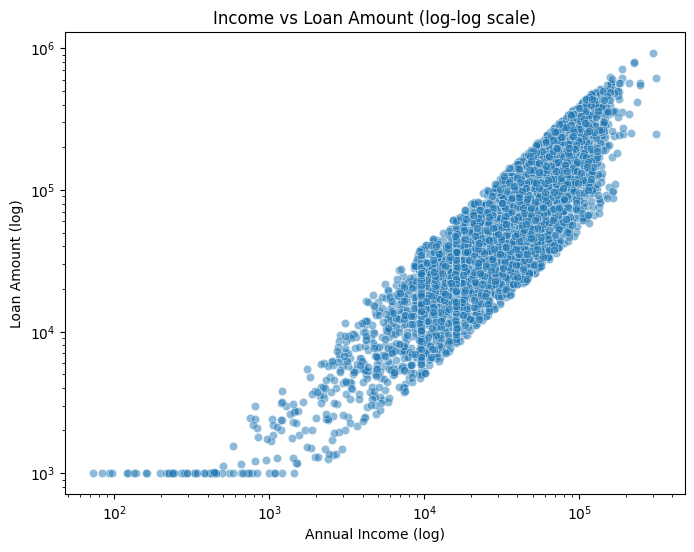

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=credit_applications_df.sample(5000),  # sample for readability
    x="annual_income",
    y="loan_amount",
    alpha=0.5
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Annual Income (log)")
plt.ylabel("Loan Amount (log)")
plt.title("Income vs Loan Amount (log-log scale)")
plt.show()


- Income vs loan amount relationships
    - step 4. Fraud flags (example rules to flag suspicious apps):


In [33]:
fraud_flags = credit_applications_df[
    (credit_applications_df["loan_to_income_ratio"] > 10) |  # loan 10x income
    (credit_applications_df["annual_income"] < 5000) & (credit_applications_df["loan_amount"] > 50000)
]
fraud_flags.head()

,application_id,customer_id,application_date,loan_amount,loan_purpose,employment_status,annual_income,debt_to_income_ratio,credit_score,application_status,default_flag,score_range,loan_to_income_ratio
3084,APP_0003085,CUST_016106,2023-08-10,1000,Education,Student,84.92,2.534,540,Declined,0,Poor (300–579),11.775789
4518,APP_0004519,CUST_024818,2022-04-06,1000,Personal,Student,82.99,2.812,651,Declined,0,Fair (580–669),12.049645
6088,APP_0006089,CUST_000202,2024-02-01,1000,Personal,Student,22.11,9.530,742,Declined,0,Very Good (740–799),45.228403
8522,APP_0008523,CUST_014128,2024-11-30,1000,Education,Student,70.13,3.300,659,Declined,0,Fair (580–669),14.259233
9864,APP_0009865,CUST_020518,2023-09-23,1000,Business,Student,65.19,3.293,770,Declined,0,Very Good (740–799),15.339776


In [35]:
# Step 1: Create Loan-to-Income Ratio
credit_applications_df["loan_to_income_ratio"] = (
    credit_applications_df["loan_amount"] / credit_applications_df["annual_income"]
)

# Step 2: Get descriptive statistics
lir_stats = credit_applications_df["loan_to_income_ratio"].describe()

print("Loan-to-Income Ratio (LIR) Descriptive Stats:")
print(lir_stats)

# Step 3: Check extreme values
high_lir = credit_applications_df[credit_applications_df["loan_to_income_ratio"] > 20]
print("\nNumber of applicants with LIR > 20:", len(high_lir))
print(high_lir[["loan_amount", "annual_income", "loan_to_income_ratio"]].head())


Loan-to-Income Ratio (LIR) Descriptive Stats:
count    100000.000000
mean          1.943417
std           2.951304
min           0.500020
25%           1.146718
50%           1.779327
75%           2.588915
max         386.100386
Name: loan_to_income_ratio, dtype: float64

Number of applicants with LIR > 20: 30
       loan_amount  annual_income  loan_to_income_ratio
6088          1000          22.11             45.228403
10152         1000          30.26             33.046927
12351         1000          41.39             24.160425
14487         1000          14.39             69.492703
23299         1000          30.26             33.046927


In [34]:
# Step 1: Create Loan-to-Income Ratio (if not already created)
credit_applications_df["loan_to_income_ratio"] = (
    credit_applications_df["loan_amount"] / credit_applications_df["annual_income"]
)

# Step 2: Overall descriptive stats
lir_stats = credit_applications_df["loan_to_income_ratio"].describe()
print("Loan-to-Income Ratio (LIR) Descriptive Stats:")
print(lir_stats)

# Step 3: Breakdown by default_flag
lir_by_default = (
    credit_applications_df.groupby("default_flag")["loan_to_income_ratio"]
    .describe()
    .reset_index()
)

print("\nLoan-to-Income Ratio (LIR) by Default Flag:")
print(lir_by_default)

# Step 4: Check extreme values (potentially suspicious cases)
high_lir = credit_applications_df[credit_applications_df["loan_to_income_ratio"] > 20]
print("\nNumber of applicants with LIR > 20:", len(high_lir))
print(high_lir[["loan_amount", "annual_income", "loan_to_income_ratio"]].head())


Loan-to-Income Ratio (LIR) Descriptive Stats:
count    100000.000000
mean          1.943417
std           2.951304
min           0.500020
25%           1.146718
50%           1.779327
75%           2.588915
max         386.100386
Name: loan_to_income_ratio, dtype: float64

Loan-to-Income Ratio (LIR) by Default Flag:
   default_flag    count      mean       std      min       25%       50%  \
0             0  98072.0  1.944487  2.977092  0.50002  1.147103  1.780039   
1             1   1928.0  1.889033  0.964923  0.50242  1.118957  1.753451   

        75%         max  
0  2.588980  386.100386  
1  2.582176   13.262599  

Number of applicants with LIR > 20: 30
       loan_amount  annual_income  loan_to_income_ratio
6088          1000          22.11             45.228403
10152         1000          30.26             33.046927
12351         1000          41.39             24.160425
14487         1000          14.39             69.492703
23299         1000          30.26             33.046